In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
ds = xr.open_dataset("Monai_Bathy.nc")

In [7]:
ds

<xarray.Dataset> Size: 393kB
Dimensions:  (y: 246, x: 394)
Coordinates:
  * y        (y) float64 2kB 0.0 0.014 0.028 0.042 ... 3.388 3.402 3.416 3.43
  * x        (x) float64 3kB 0.0 0.014 0.028 0.042 ... 5.46 5.474 5.488 5.502
Data variables:
    z        (y, x) float32 388kB ...
Attributes:
    Conventions:  CF-1.7
    title:        Produced by grdmath
    history:      gmt grdmath Bathy_D.nc?z -1 MUL = Monai_Bathy.nc
    description:  
    GMT_version:  6.4.0 [64-bit]

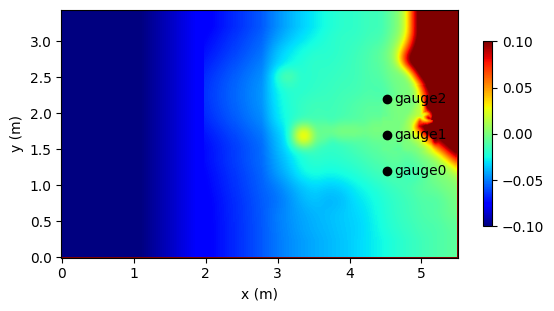

In [34]:
plt.pcolormesh(ds["x"],ds["y"],ds["z"], cmap="jet")
plt.clim([-0.1, 0.1])
cbar = plt.colorbar(shrink=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
# add gauge data
gauge_x = [4.521, 4.521, 4.521]
gauge_y = [1.196, 1.696, 2.196]
labels = ['gauge0','gauge1','gauge2']
plt.scatter(gauge_x, gauge_y, color='k', marker='o')
# Add labels
for xi, yi, label in zip(gauge_x, gauge_y, labels):
    plt.text(xi+0.1, yi-0.1, label, fontsize=10,
             ha='left', va='bottom')

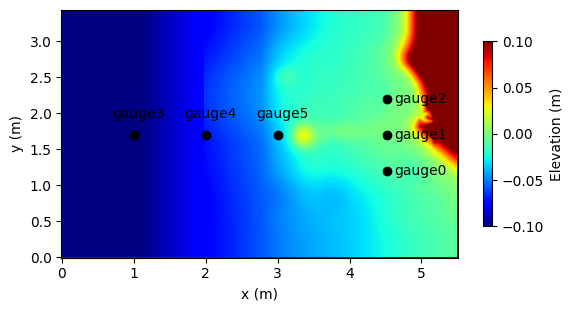

In [6]:
plt.pcolormesh(ds["x"],ds["y"],ds["z"], cmap="jet")
plt.clim([-0.1, 0.1])
cbar = plt.colorbar(shrink=0.5)
cbar.set_label('Elevation (m)')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
# add gauge data
gauge_x = [4.521, 4.521, 4.521]
gauge_y = [1.196, 1.696, 2.196]
labels = ['gauge0','gauge1','gauge2']
plt.scatter(gauge_x, gauge_y, color='k', marker='o')
# Add labels
for xi, yi, label in zip(gauge_x, gauge_y, labels):
    plt.text(xi+0.1, yi-0.1, label, fontsize=10,
             ha='left', va='bottom')
hgauge_x = [1.000, 2.000, 3.000]
hgauge_y = [1.696, 1.696, 1.696]
hlabels = ['gauge3','gauge4','gauge5']
plt.scatter(hgauge_x, hgauge_y, color='k', marker='o')
# Add labels
for xi, yi, label in zip(hgauge_x, hgauge_y, hlabels):
    plt.text(xi-0.3, yi+0.2, label, fontsize=10,
             ha='left', va='bottom')
plt.savefig('Monai_Bathy.png', dpi=300, bbox_inches='tight')

In [13]:
tide_data = np.loadtxt("MonaiValley_WaveGages_30s_02s.txt",skiprows=1)

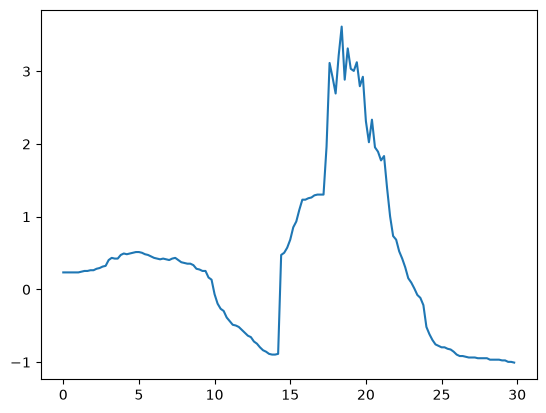

In [34]:
plt.plot(tide_data[:,0],tide_data[:,1])

## View checkpoint data

--- Checkpoint Contents ---
Saved at Epoch: 156
Best Loss achieved: 0.0000002153


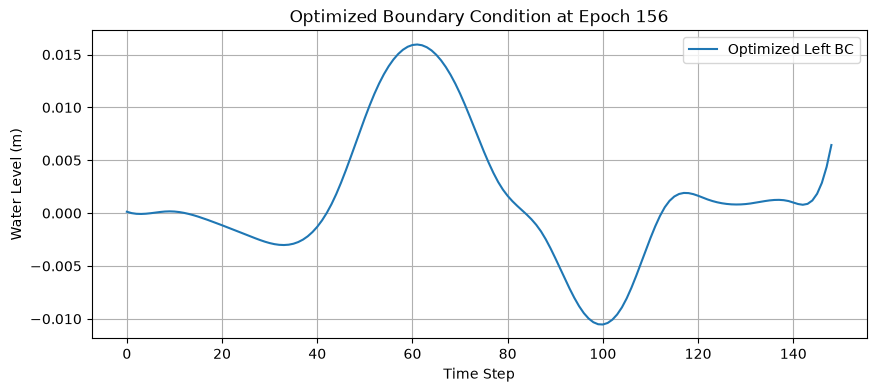

In [2]:
import torch

# 1. Load the checkpoint using PyTorch
# We use map_location='cpu' so you can inspect this on any machine, even without a GPU
checkpoint = torch.load("./inverse_results_spline/best_inverse_checkpoint.pth", map_location="cpu", weights_only=True)

# 2. See what is inside
print("--- Checkpoint Contents ---")
print(f"Saved at Epoch: {checkpoint['epoch']}")
print(f"Best Loss achieved: {checkpoint['train_loss']:.10f}")

# 3. Extract your optimized boundary condition parameter
# It is saved as a PyTorch tensor, so we convert it to a standard Numpy array to read it easily
bc_array = checkpoint['boundary_series'].numpy()

# 4. Optional: Plot the waveform!
plt.figure(figsize=(10, 4))
plt.plot(bc_array, label="Optimized Left BC")
plt.title(f"Optimized Boundary Condition at Epoch {checkpoint['epoch']}")
plt.xlabel("Time Step")
plt.ylabel("Water Level (m)")
plt.grid(True)
plt.legend()
plt.show()

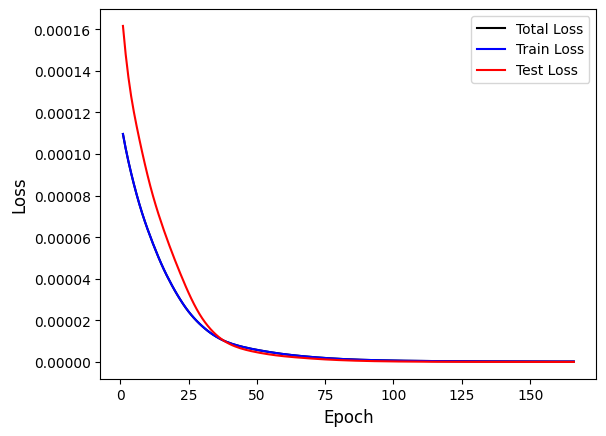

In [2]:
loss = np.loadtxt('./inverse_results_spline/loss_history.txt',skiprows=1)
plt.plot(loss[:,0],loss[:,1],label='Total Loss',color='k')
plt.plot(loss[:,0],loss[:,2],label='Train Loss',color='b')
plt.plot(loss[:,0],loss[:,3],label='Test Loss',color='r')
plt.xlabel('Epoch',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.legend()
plt.savefig('./plot/loss_history_a.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

In [3]:
gauge_data = np.loadtxt("./inverse_results_spline/best_gauge_comparison.txt",skiprows=1)

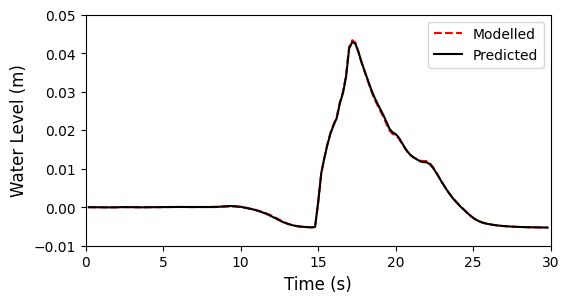

In [4]:
plt.figure(figsize=(6, 3))
#plt.plot(gauge_data[:,0],gauge_data[:,1],gauge_data[:,0],gauge_data[:,2])
#plt.plot(gauge_data[:,0],gauge_data[:,3],gauge_data[:,0],gauge_data[:,4])
# plt.plot(gauge_data[:,0],gauge_data[:,5],gauge_data[:,0],gauge_data[:,6]) # test gauge
plt.plot(gauge_data[:,0],gauge_data[:,6],label='Modelled',color='r',linestyle='dashed')
plt.plot(gauge_data[:,0],gauge_data[:,5],label='Predicted',color='k')
plt.xlabel('Time (s)',fontsize=12)
plt.ylabel('Water Level (m)',fontsize=12)
plt.xlim([0,30])
plt.ylim([-0.01,0.05])
plt.legend()
plt.savefig('./plot/inverse_bc_test_plot.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

### Compare with input wave

In [2]:
wl = np.load('./inverse_results_spline/boundary_evolution_history.npy')

In [8]:
time = np.arange(0.2, 29.8 + 0.2, 0.2)

In [3]:
input_wave = np.loadtxt('../input_wave_002s.txt')

In [15]:
wl.shape

(166, 149)

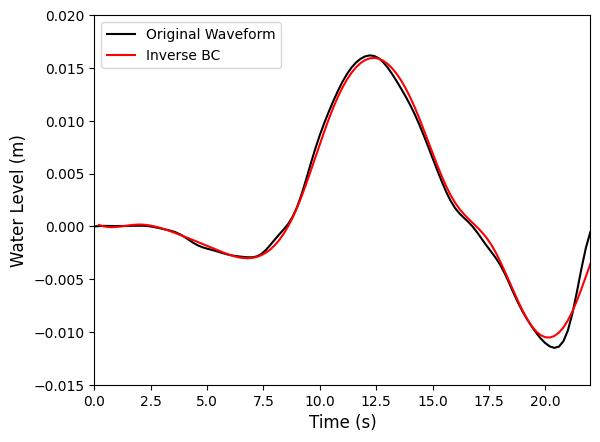

In [5]:
wl = np.load('./inverse_results_spline/boundary_evolution_history.npy')
time = np.arange(0.2, 29.8 + 0.2, 0.2)
input_wave = np.loadtxt('../input_wave_002s.txt')
# Plot
plt.plot(input_wave[:,0],input_wave[:,1],label='Original Waveform', color='k')
plt.plot(time,wl[153,:],label='Inverse BC',color='r')
plt.xlabel('Time (s)',fontsize=12)
plt.ylabel('Water Level (m)',fontsize=12)
plt.legend(loc ='upper left')
plt.xlim([0,22])
plt.ylim([-0.015,0.02])
plt.savefig('./plot/inverse_bc_plot.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

In [25]:
for i in range(0,155):
    plt.plot(input_wave[:,0],input_wave[:,1],label='Original Waveform', color='k')
    plt.plot(time,wl[i,:],label='Inverse BC',color='r')
    plt.xlabel('Time (s)')
    plt.ylabel('Water Level (m)')
    plt.legend(loc ='upper left')
    plt.xlim([0,22])
    plt.ylim([-0.015,0.02])
    plt.title(f'Epoch = {i+1}')
    plt.savefig(f'./fig/{i}.png')
    plt.close()

Make a video

In [28]:
import os
import moviepy.video.io.ImageSequenceClip


frames = []

for i in range(0,155): 
    frames.append('./fig/' + str(i) + '.png') 

fps = 20

clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(frames, fps=fps)
clip.write_videofile( 'video.mp4')

Moviepy - Building video video.mp4.
Moviepy - Writing video video.mp4



t:  18%|█▊        | 28/155 [00:00<00:01, 69.94it/s, now=None]

Moviepy - Done !
Moviepy - video ready video.mp4


In [4]:
control

array([[-0.0002842 , -0.00028426, -0.00028429, ..., -0.00028094,
         0.00024785,  0.00017579],
       [-0.00056349, -0.00055822, -0.00055357, ..., -0.00055101,
         0.00050272,  0.00035111],
       [-0.00083638, -0.00081889, -0.00079936, ..., -0.00080396,
         0.00076392,  0.00052806],
       ...,
       [ 0.00013622, -0.0003427 ,  0.00060336, ...,  0.00178892,
        -0.00040477,  0.0067576 ],
       [ 0.00013637, -0.00034237,  0.00060269, ...,  0.00178474,
        -0.00040306,  0.00676759],
       [ 0.0001365 , -0.00034203,  0.00060203, ...,  0.00178059,
        -0.00040133,  0.00677741]])

(-0.015, 0.02)

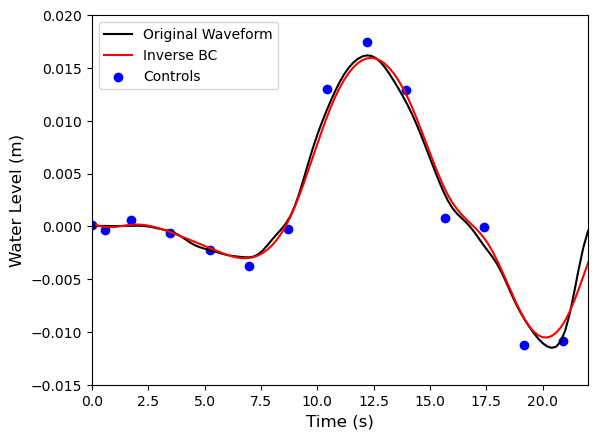

In [7]:
wl = np.load('./inverse_results_spline/boundary_evolution_history.npy')
control = np.load('./inverse_results_spline/control_evolution_history.npy')
optimized_control = np.loadtxt('./inverse_results_spline/optimized_spline_controls.txt')
time = np.arange(0.2, 29.8 + 0.2, 0.2)
input_wave = np.loadtxt('../input_wave_002s.txt')
# Plot
plt.plot(input_wave[:,0],input_wave[:,1],label='Original Waveform', color='k')
plt.plot(time,wl[153,:],label='Inverse BC',color='r')
plt.scatter(optimized_control[:,0],control[153,:],label='Controls',color='b')
plt.xlabel('Time (s)',fontsize=12)
plt.ylabel('Water Level (m)',fontsize=12)
plt.legend(loc ='upper left')
plt.xlim([0,22])
plt.ylim([-0.015,0.02])
#plt.savefig('./plot/inverse_bc_plot.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

In [12]:
for i in range(0,155):
    plt.plot(input_wave[:,0],input_wave[:,1],label='Original Waveform', color='k')
    plt.plot(time,wl[i,:],label='Inverse BC',color='r')
    plt.scatter(optimized_control[:,0],control[i,:],label='Controls',color='b')
    plt.xlabel('Time (s)',fontsize=12)
    plt.ylabel('Water Level (m)',fontsize=12)
    plt.legend(loc ='upper left')
    plt.xlim([0,22])
    plt.ylim([-0.015,0.02])
    plt.title(f'Epoch = {i+1}')
    plt.savefig(f'./fig1/{i}.png', bbox_inches='tight', pad_inches=0.1)
    plt.close()

In [13]:
import os
import moviepy.video.io.ImageSequenceClip


frames = []

for i in range(0,155): 
    frames.append('./fig1/' + str(i) + '.png') 

fps = 20

clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(frames, fps=fps)
clip.write_videofile( 'video_new_fps20.mp4')

Moviepy - Building video video_new_fps20.mp4.
Moviepy - Writing video video_new_fps20.mp4



Moviepy - Done !
Moviepy - video ready video_new_fps20.mp4
